In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import math
import seaborn as sns
import json
import geopandas as gdp

In [2]:
%matplotlib inline

In [3]:
oa_lookup = pd.read_csv('../data/OA11_OA21_LAD22_EW_LU_Exact_fit_V2_7175137222568651779.csv')
oa_lookup.head()

/var/folders/jr/scz17gjs3zd226jcsn8k38480000gn/T/ipykernel_13917/2225680027.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_lookup = pd.read_csv('../data/OA11_OA21_LAD22_EW_LU_Exact_fit_V2_7175137222568651779.csv')


,OA11CD,OA21CD,CHNGIND,LAD22CD,LAD22NM,LAD22NMW,ObjectId
0,E00000124,E00000124,U,E09000002,Barking and Dagenham,NaN,1
1,E00000125,E00000125,U,E09000002,Barking and Dagenham,NaN,2
2,E00000128,E00000128,U,E09000002,Barking and Dagenham,NaN,3
3,E00000129,E00000129,U,E09000002,Barking and Dagenham,NaN,4
4,E00000130,E00000130,U,E09000002,Barking and Dagenham,NaN,5


In [4]:
urb_rur_lookup = pd.read_csv('../data/RUC11_OA11_EW.csv')
urb_rur_lookup.head()

,OA11CD,RUC11CD,RUC11,BOUND_CHGIND,ASSIGN_CHGIND,ASSIGN_CHREASON
0,E00000001,A1,Urban major conurbation,U,NaN,NaN
1,E00000003,A1,Urban major conurbation,U,NaN,NaN
2,E00000005,A1,Urban major conurbation,U,NaN,NaN
3,E00000007,A1,Urban major conurbation,U,NaN,NaN
4,E00000010,A1,Urban major conurbation,U,NaN,NaN


In [5]:
oa_classification = oa_lookup[['OA11CD', 'OA21CD', 'LAD22NM']].merge(
    urb_rur_lookup[['OA11CD', 'RUC11CD', 'RUC11']],
    how='inner',
    left_on='OA11CD',
    right_on='OA11CD'
)

oa_classification.head()

,OA11CD,OA21CD,LAD22NM,RUC11CD,RUC11
0,E00000124,E00000124,Barking and Dagenham,A1,Urban major conurbation
1,E00000125,E00000125,Barking and Dagenham,A1,Urban major conurbation
2,E00000128,E00000128,Barking and Dagenham,A1,Urban major conurbation
3,E00000129,E00000129,Barking and Dagenham,A1,Urban major conurbation
4,E00000130,E00000130,Barking and Dagenham,A1,Urban major conurbation


In [6]:
geo_df = gdp.read_file('../geo_data/OA_2021_EW_BFC_V8.shp')
geo_df.head()

,OA21CD,LSOA21CD,LSOA21NM,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,geometry
0,E00000001,E01000001,City of London 001A,None,532250,181864,51.5202,-0.09523,09af0f57-ef7c-448b-b0ba-093649a86e70,"POLYGON ((532303.492 181814.110, 532301.242 18..."
1,E00000003,E01000001,City of London 001A,None,532171,181819,51.5198,-0.09638,be17a101-45e8-4e24-8f46-ecf5ae97ad13,"POLYGON ((532213.378 181846.192, 532213.954 18..."
2,E00000005,E01000001,City of London 001A,None,532166,181722,51.5190,-0.09649,cf9938e7-ce0a-4c09-9692-56d458696e28,"POLYGON ((532180.131 181763.020, 532177.000 18..."
3,E00000007,E01000001,City of London 001A,None,532088,181473,51.5167,-0.09771,297029c6-4f99-44c8-9392-ba6758ac99d5,"POLYGON ((532201.292 181668.180, 532205.000 18..."
4,E00000010,E01000003,City of London 001C,None,532092,182114,51.5225,-0.09741,eee105a5-6df7-41b7-ba8e-d77deb24493f,"POLYGON ((532127.958 182133.192, 532106.413 18..."


In [7]:
geo_df.to_crs(epsg=3857, inplace=True)

In [8]:
columns = ['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'uprn'] + ['method', 'UPRN', 'x_coord', 'y_coord', 'lat', 'lon']
sale_prices = pd.read_csv('../data/pp-complete-with-location.csv', header=0, names=columns)

/var/folders/jr/scz17gjs3zd226jcsn8k38480000gn/T/ipykernel_13917/1807105069.py:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  sale_prices = pd.read_csv('../data/pp-complete-with-location.csv', header=0, names=columns)


In [9]:
sale_prices.tail()

,id,price,date,postcode,property_type,old_new,duration,paon,saon,street,...,county,ppd_category,record_status,uprn,method,UPRN,x_coord,y_coord,lat,lon
27808235,{12A8BAB6-A9F1-2125-E063-4804A8C08CC1},235000,2024-01-24 00:00,S13 9AG,S,N,F,28A,NaN,HALL ROAD,...,SOUTH YORKSHIRE,A,A,10091131170,method8,10091131170,440846.03,386382.68,53.372751,-1.387538
27808236,{12A8BAB6-A9F4-2125-E063-4804A8C08CC1},165500,2024-02-07 00:00,S71 1UZ,S,N,F,17,NaN,RICHARD AVENUE,...,SOUTH YORKSHIRE,A,A,100050652863,method8,100050652863,435179.00,408620.00,53.573028,-1.470231
27808237,{12A8BAB6-A9F5-2125-E063-4804A8C08CC1},120000,2024-01-26 00:00,S5 8TX,T,N,F,22,NaN,PENRITH CRESCENT,...,SOUTH YORKSHIRE,A,A,100051051597,method8,100051051597,434227.91,390584.08,53.410982,-1.486552
27808238,{12A8BAB6-A9F6-2125-E063-4804A8C08CC1},260000,2024-01-19 00:00,S35 0HL,T,N,F,9,NaN,ORCHARD STREET,...,SOUTH YORKSHIRE,A,A,100051046423,method8,100051046423,430728.27,393451.91,53.436973,-1.538920
27808239,{12A8BAB6-A9FD-2125-E063-4804A8C08CC1},135000,2024-02-01 00:00,DN12 3NN,S,N,F,12,NaN,DENABY AVENUE,...,SOUTH YORKSHIRE,A,A,100050717002,method8,100050717002,450159.00,398594.00,53.481704,-1.245636


In [10]:
from shapely.geometry import Point, Polygon

In [11]:
from geopandas import GeoDataFrame
geometry = [Point(xy) for xy in zip(sale_prices['lon'], sale_prices['lat'])]
crs="EPSG:4326"
sale_gdf = GeoDataFrame(sale_prices, geometry=geometry, crs=crs)
sale_gdf = sale_gdf.to_crs('3857')
sale_gdf.head()

,id,price,date,postcode,property_type,old_new,duration,paon,saon,street,...,ppd_category,record_status,uprn,method,UPRN,x_coord,y_coord,lat,lon,geometry
0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,LANGLEY CLOSE,...,A,A,200004603747,NaN,200004603747,382845.63,350560.34,53.052039,-2.257366,POINT (-251288.811 6992629.515)
1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,ROSSETTI ROAD,...,A,A,200003407696,NaN,200003407696,534752.00,178381.00,51.488331,-0.060520,POINT (-6737.100 6708132.673)
2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,LAWNSWOOD ROAD,...,A,A,90146241,NaN,90146241,388725.00,287130.00,52.481988,-2.167445,POINT (-241278.818 6887748.738)
3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,NaN,...,A,A,10033006155,NaN,10033006155,476090.00,202835.00,51.719093,-0.899908,POINT (-100177.323 6749492.419)
4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,INLANDS CLOSE,...,A,A,100120995350,NaN,100120995350,416378.00,160302.00,51.341568,-1.766247,POINT (-196617.661 6681937.058)


In [12]:
helpful = sale_gdf.sjoin(geo_df,how="inner", predicate='intersects')
taha = helpful.merge(oa_classification, how='inner', left_on='OA21CD', right_on='OA21CD')
taha.head()

,id,price,date,postcode,property_type,old_new,duration,paon,saon,street,...,LSOA21NMW,BNG_E,BNG_N,LAT,LONG,GlobalID,OA11CD,LAD22NM,RUC11CD,RUC11
0,{8524B47D-47ED-4C6B-97BF-D114570165DE},56950,1995-10-20 00:00,ST5 7UE,D,Y,F,2,NaN,LANGLEY CLOSE,...,None,382958,350522,53.0517,-2.25568,90f84fb9-7769-408d-b6fd-de6ba3f7974a,E00150541,Newcastle-under-Lyme,C1,Urban city and town
1,{92A77299-BCFF-433B-B54D-D114861197D7},56952,1995-03-31 00:00,SE16 3EY,F,Y,L,3,FLAT 27,ROSSETTI ROAD,...,None,534744,178409,51.4886,-0.06062,9b51340d-055b-40a9-98ea-8dc7f71415dd,E00020342,Southwark,A1,Urban major conurbation
2,{AECA5453-F149-46BF-B3E3-CA05B7E47CE5},74000,1995-12-01 00:00,DY8 5PW,D,N,F,66,NaN,LAWNSWOOD ROAD,...,None,388758,287094,52.4817,-2.16695,6d9c7f60-fbdf-47c0-9fcf-44e33ce58000,E00050170,Dudley,A1,Urban major conurbation
3,{6785BDEE-16CA-4D80-8131-CA05D4F4DBE0},155000,1995-08-09 00:00,OX39 4AF,D,Y,F,THE PANTILES,NaN,NaN,...,None,475205,202749,51.7184,-0.91273,c164dfa4-5dcd-49df-bd1b-5d0711348862,E00145755,South Oxfordshire,F1,Rural hamlets and isolated dwellings
4,{3FAA4BB3-40B8-4003-8C5B-D494636C6410},75000,1995-09-08 00:00,SN9 5HD,D,N,F,6,NaN,INLANDS CLOSE,...,None,416420,160241,51.3410,-1.76564,e811fe8e-d1a6-4684-beda-28251c42ebac,E00162545,Wiltshire,D1,Rural town and fringe


In [13]:
taha.shape

(27919706, 38)

In [14]:
print(columns)

['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'uprn', 'method', 'UPRN', 'x_coord', 'y_coord', 'lat', 'lon']


In [15]:
smaller_col_list = columns + ['OA11CD', 'LAD22NM', 'RUC11CD', 'RUC11']
print(smaller_col_list)


['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'uprn', 'method', 'UPRN', 'x_coord', 'y_coord', 'lat', 'lon', 'OA11CD', 'LAD22NM', 'RUC11CD', 'RUC11']


In [16]:
type(taha)

geopandas.geodataframe.GeoDataFrame

In [17]:
smaller = taha[smaller_col_list]
type(smaller)

pandas.core.frame.DataFrame

In [18]:
smaller.to_csv('../data/all_sales_data_with_classification.csv')

# Getting on our big boy pants

In [3]:
#cols = ['id', 'price', 'date', 'postcode', 'property_type', 'old_new', 'duration', 'paon', 'saon', 'street', 'locality', 'town', 'district', 'county', 'ppd_category', 'record_status', 'uprn', 'parentuprn', 'usrn', 'x_coord', 'y_coord', 'lat', 'lon', 'OA11CD', 'LAD22NM', 'RUC11CD', 'RUC11']
smaller = pd.read_csv('../data/all_sales_data_with_classification.csv')
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,parentuprn,usrn,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11
0,0,{40FD4DF2-5362-407C-92BC-566E2CCE89E9},44500,1995-02-03,SR6 0AQ,T,N,F,50,NaN,...,NaN,38734115,439764.0,557681.0,54.912270,-1.381292,E00170219,Sunderland,A1,Urban major conurbation
1,1,{7A99F89E-7D81-4E45-ABD5-566E49A045EA},56500,1995-01-13,CO6 1SQ,T,N,F,19,NaN,...,NaN,3900242,585448.0,223310.0,51.877526,0.692765,E00108589,Braintree,D1,Rural town and fringe
2,2,{28225260-E61C-4E57-8B56-566E5285B1C1},58000,1995-07-28,B90 4TG,T,N,F,37,NaN,...,NaN,35005306,413632.0,276827.0,52.389317,-1.801110,E00051642,Solihull,A1,Urban major conurbation
3,3,{AE76CAF1-F8CC-43F9-8F63-4F48A2857D41},17000,1995-03-10,S65 1QJ,T,N,L,22,NaN,...,NaN,32601135,443444.0,393520.0,53.436695,-1.347514,E00039354,Rotherham,B1,Urban minor conurbation
4,4,{709FB471-3690-4945-A9D6-4F48CE65AAB6},58000,1995-04-28,PE7 3AL,D,Y,F,4,NaN,...,NaN,17804028,519984.0,294640.0,52.536432,-0.232422,E00091868,Huntingdonshire,C1,Urban city and town


In [58]:
smaller.groupby('RUC11').price.describe()

,count,mean,std,min,25%,50%,75%,max
RUC11,,,,,,,,
Rural hamlets and isolated dwellings,590149.0,326778.028218,544280.913759,100.0,143500.0,247995.0,400000.0,150000000.0
Rural hamlets and isolated dwellings in a sparse setting,73333.0,228355.512430,249561.786365,100.0,105000.0,185000.0,292000.0,26500000.0
Rural town and fringe,2529302.0,186559.147266,246238.814342,100.0,86950.0,151000.0,237500.0,111921434.0
Rural town and fringe in a sparse setting,155741.0,161599.962707,166798.476217,100.0,76500.0,135000.0,205000.0,21771447.0
Rural village,1242110.0,258314.570637,400167.308278,100.0,120000.0,200000.0,324000.0,123965000.0
Rural village in a sparse setting,130297.0,183510.787616,197219.368047,200.0,82000.0,147500.0,233000.0,22198935.0
Urban city and town,12406863.0,170987.522685,309897.269223,1.0,78000.0,135000.0,210000.0,140000000.0
Urban city and town in a sparse setting,71150.0,132001.559452,142159.479293,300.0,67500.0,115000.0,170000.0,22198935.0
Urban major conurbation,7179427.0,235046.482060,911479.717242,1.0,82000.0,148000.0,250000.0,594300000.0


In [4]:
smaller.loc[:, 'datey'] = pd.to_datetime(smaller.date)
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,usrn,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey
0,0,{40FD4DF2-5362-407C-92BC-566E2CCE89E9},44500,1995-02-03,SR6 0AQ,T,N,F,50,NaN,...,38734115,439764.0,557681.0,54.912270,-1.381292,E00170219,Sunderland,A1,Urban major conurbation,1995-02-03
1,1,{7A99F89E-7D81-4E45-ABD5-566E49A045EA},56500,1995-01-13,CO6 1SQ,T,N,F,19,NaN,...,3900242,585448.0,223310.0,51.877526,0.692765,E00108589,Braintree,D1,Rural town and fringe,1995-01-13
2,2,{28225260-E61C-4E57-8B56-566E5285B1C1},58000,1995-07-28,B90 4TG,T,N,F,37,NaN,...,35005306,413632.0,276827.0,52.389317,-1.801110,E00051642,Solihull,A1,Urban major conurbation,1995-07-28
3,3,{AE76CAF1-F8CC-43F9-8F63-4F48A2857D41},17000,1995-03-10,S65 1QJ,T,N,L,22,NaN,...,32601135,443444.0,393520.0,53.436695,-1.347514,E00039354,Rotherham,B1,Urban minor conurbation,1995-03-10
4,4,{709FB471-3690-4945-A9D6-4F48CE65AAB6},58000,1995-04-28,PE7 3AL,D,Y,F,4,NaN,...,17804028,519984.0,294640.0,52.536432,-0.232422,E00091868,Huntingdonshire,C1,Urban city and town,1995-04-28


In [5]:
smaller.loc[:, 'yeary'] = smaller.datey.apply(lambda x: x.year)
smaller.head()

,Unnamed: 0,id,price,date,postcode,property_type,old_new,duration,paon,saon,...,x_coord,y_coord,lat,lon,OA11CD,LAD22NM,RUC11CD,RUC11,datey,yeary
0,0,{40FD4DF2-5362-407C-92BC-566E2CCE89E9},44500,1995-02-03,SR6 0AQ,T,N,F,50,NaN,...,439764.0,557681.0,54.912270,-1.381292,E00170219,Sunderland,A1,Urban major conurbation,1995-02-03,1995
1,1,{7A99F89E-7D81-4E45-ABD5-566E49A045EA},56500,1995-01-13,CO6 1SQ,T,N,F,19,NaN,...,585448.0,223310.0,51.877526,0.692765,E00108589,Braintree,D1,Rural town and fringe,1995-01-13,1995
2,2,{28225260-E61C-4E57-8B56-566E5285B1C1},58000,1995-07-28,B90 4TG,T,N,F,37,NaN,...,413632.0,276827.0,52.389317,-1.801110,E00051642,Solihull,A1,Urban major conurbation,1995-07-28,1995
3,3,{AE76CAF1-F8CC-43F9-8F63-4F48A2857D41},17000,1995-03-10,S65 1QJ,T,N,L,22,NaN,...,443444.0,393520.0,53.436695,-1.347514,E00039354,Rotherham,B1,Urban minor conurbation,1995-03-10,1995
4,4,{709FB471-3690-4945-A9D6-4F48CE65AAB6},58000,1995-04-28,PE7 3AL,D,Y,F,4,NaN,...,519984.0,294640.0,52.536432,-0.232422,E00091868,Huntingdonshire,C1,Urban city and town,1995-04-28,1995


In [67]:
a.groupby('yeary').price.median().values

array([ 85000. ,  90000. ,  98000. , 110000. , 125000. , 137750. ,
       157997.5, 185000. , 220000. , 249995. , 260000. , 280000. ,
       300000. , 295000. , 275000. , 300000. , 285000. , 285000. ,
       284995. , 292000. , 305000. , 320000. , 335000. , 340000. ,
       345000. , 370000. , 425000. , 602500. ])

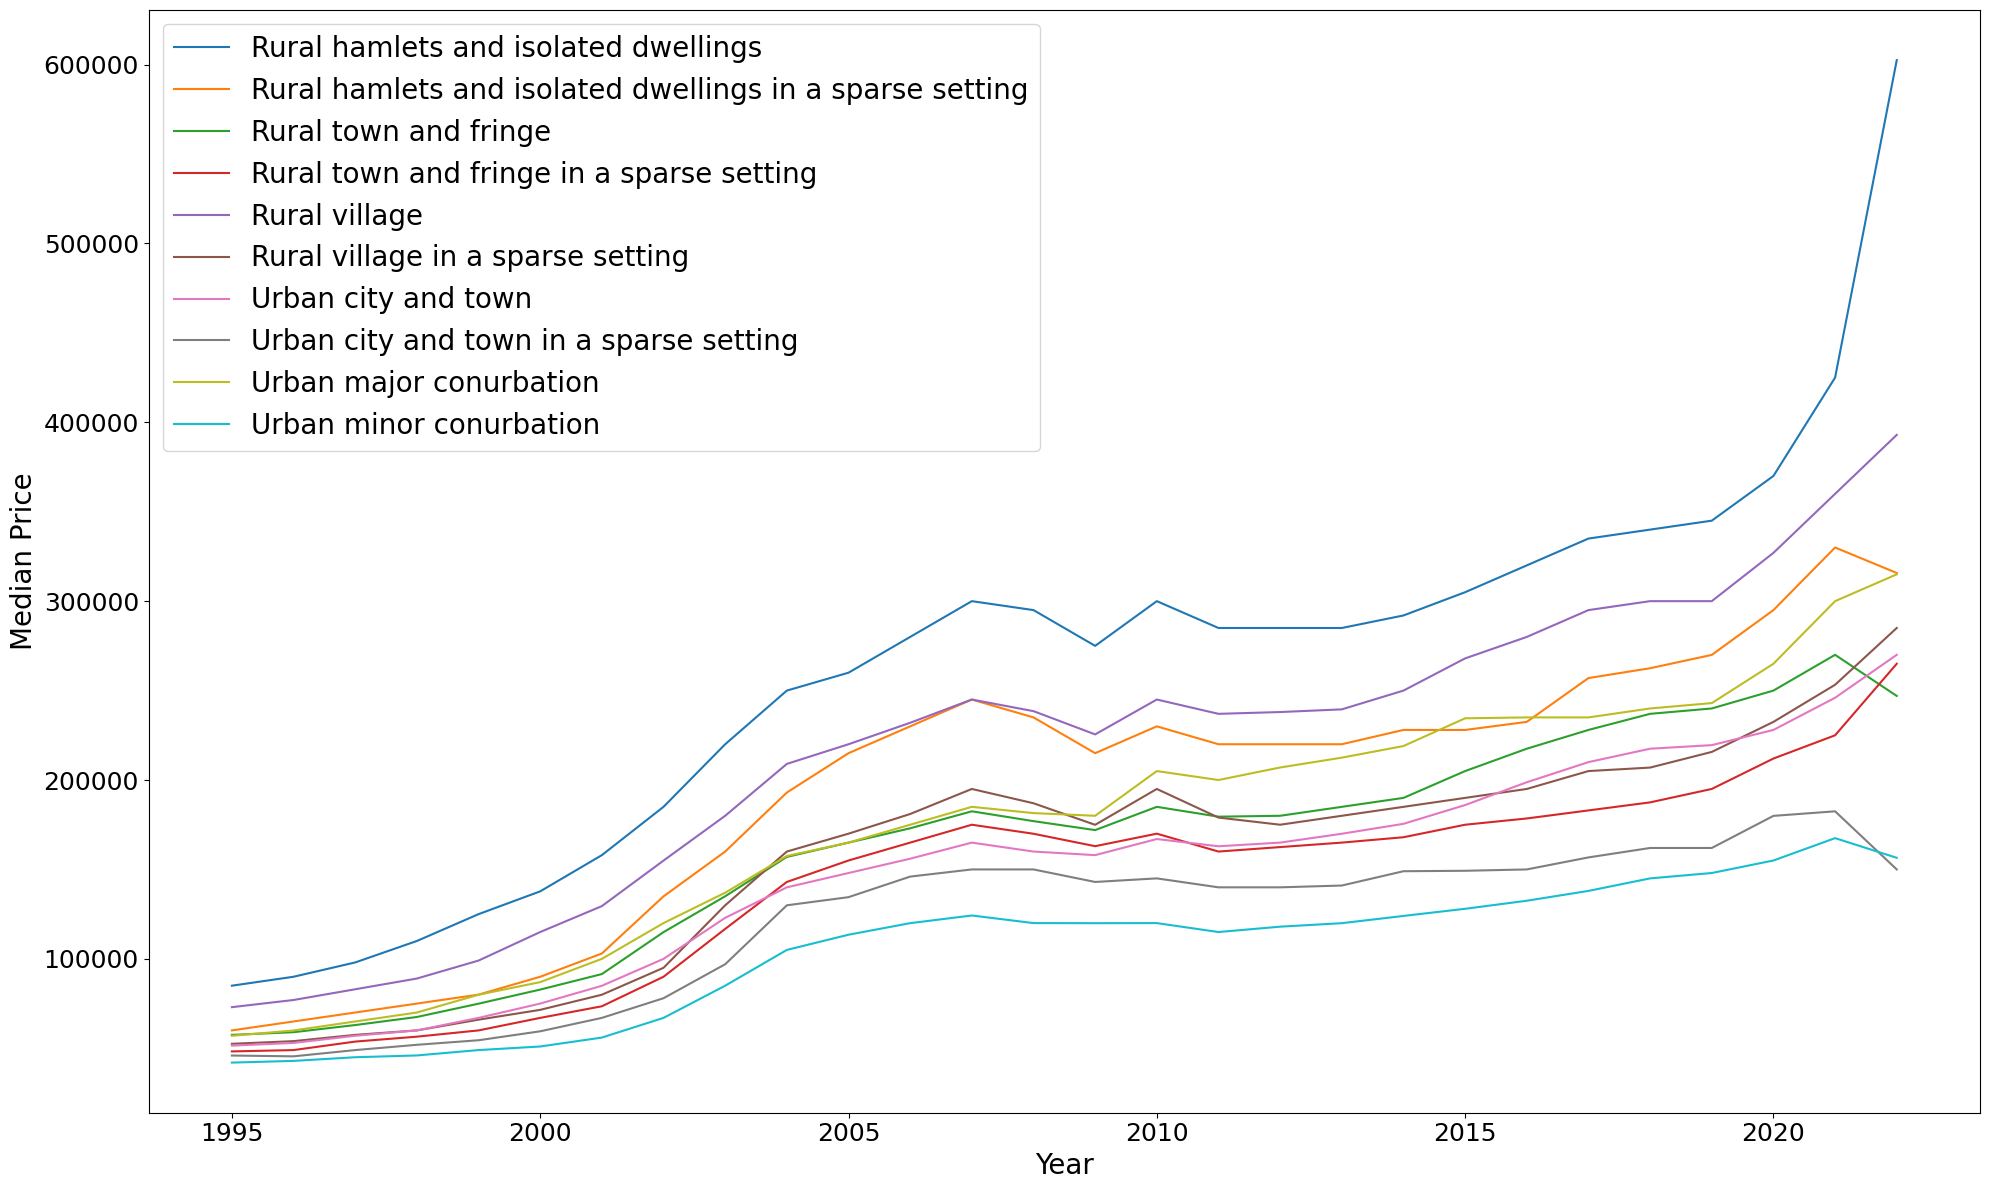

In [6]:
fig, ax = plt.subplots(figsize=(20,12))
for typey, frame in smaller.groupby('RUC11'):
    a = frame.groupby('yeary').price.median()
    plt.plot(a.index, a.values, label=typey)

plt.legend(fontsize=20)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Median Price', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.show()